Loading CSV data...
Skills feature shape: (500, 60)
Category feature shape: (500, 24)
MAE: 25497.67
MSE: 963699834.14
R2 Score: -0.11
Future skill chart saved: future_skill_chart.png
WordCloud saved: future_skill_wordcloud.png
✅ Future Analysis & Salary Prediction Completed Successfully!


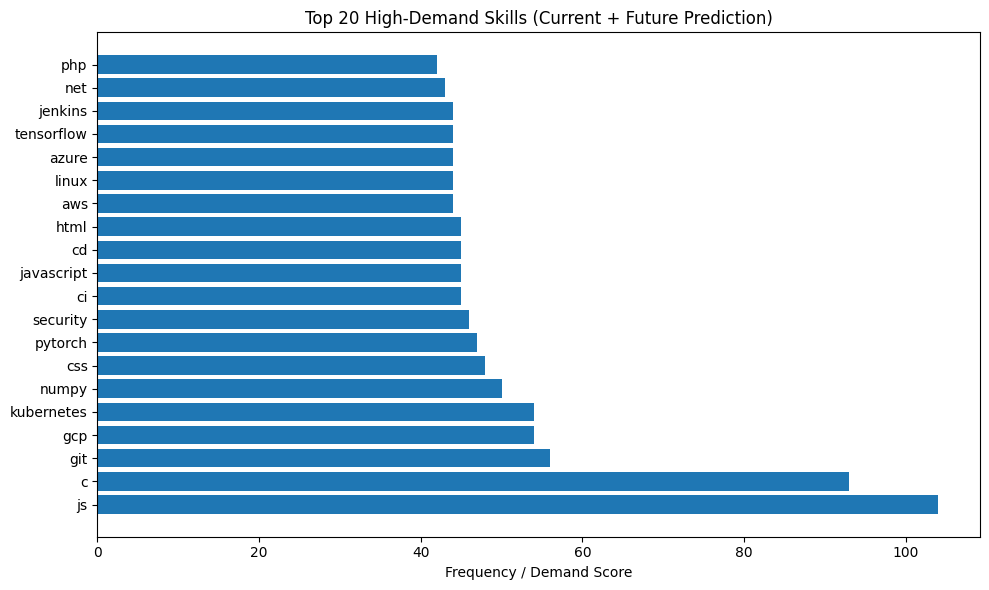

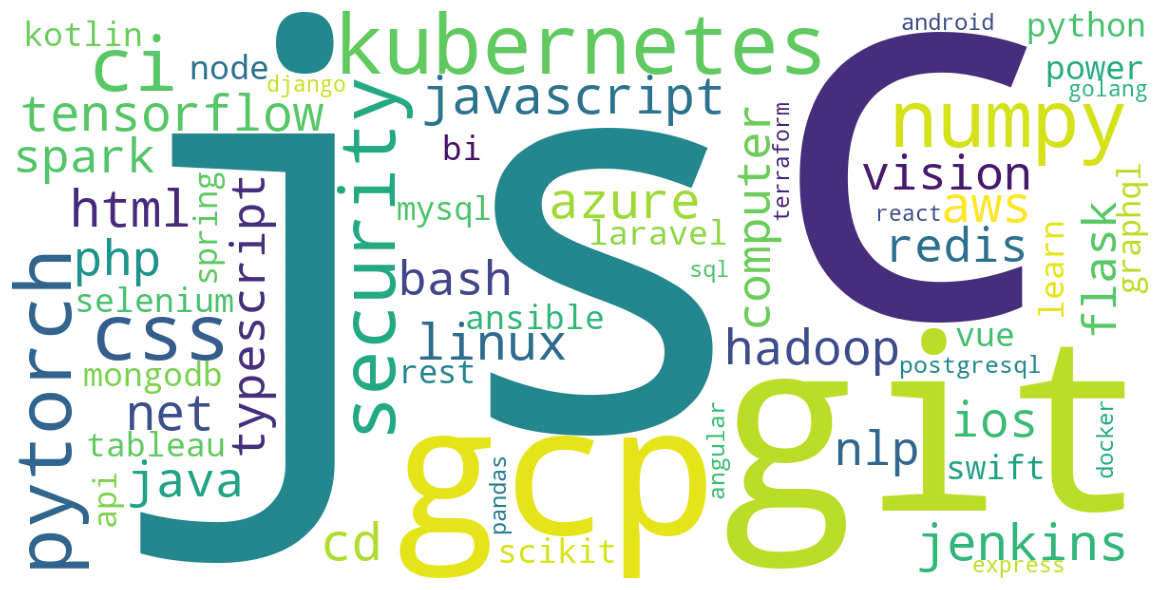

In [5]:
# future_analysis_model.py
# ------------------------
# উদ্দেশ্য: Future Job Skill Demand এবং Salary Prediction
# ------------------------

import pandas as pd
import re
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.preprocessing import OneHotEncoder
from scipy.sparse import hstack
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# ------------------------
# HELPER FUNCTION
# ------------------------
def clean_text(text):
    """
    টেক্সট পরিষ্কার করার ফাংশন
    - ছোট অক্ষরে রূপান্তর
    - punctuation রিমুভ
    """
    text = str(text).lower()
    text = re.sub(r"[^a-zA-Z0-9 ]", " ", text)
    return text

# ------------------------
# CSV লোড
# ------------------------
print("Loading CSV data...")
df = pd.read_csv("jobs.csv")

# ------------------------
# Salary কলাম পরিষ্কার এবং numeric তে রূপান্তর
# ------------------------
def parse_salary(text):
    """
    Salary টেক্সট থেকে numeric value বের করার ফাংশন
    যেমন: 'Tk. 15,000 - 35,000 (Monthly)' -> 25000
    """
    if pd.isna(text):
        return None
    text = str(text).lower()
    text = re.sub(r'[,$€£৳]', '', text)
    text = text.replace('tk.', '').replace('tk', '').replace('bdt', '').replace('usd', '').replace('aud', '')
    text = re.sub(r'(\d+)k', lambda m: str(int(m.group(1))*1000), text)
    nums = re.findall(r'\d+', text)
    if not nums:
        return None
    nums = list(map(int, nums))
    if len(nums) >= 2:
        return (nums[0] + nums[1]) / 2
    return nums[0]

df['SalaryNum'] = df['Salary'].apply(parse_salary)

# ------------------------
# Feature Engineering
# ------------------------

# 1️⃣ Skills → Bag-of-Words
df['Skills_clean'] = df['Skills'].fillna('').apply(clean_text)
vectorizer = CountVectorizer()
X_skills = vectorizer.fit_transform(df['Skills_clean'])
print(f"Skills feature shape: {X_skills.shape}")

# 2️⃣ Category → One-Hot Encoding
encoder = OneHotEncoder()
X_cat = encoder.fit_transform(df[['Category']])
print(f"Category feature shape: {X_cat.shape}")

# 3️⃣ Experience → Numeric
def parse_experience(text):
    if pd.isna(text):
        return 0
    match = re.search(r'\d+', str(text))
    if match:
        return int(match.group(0))
    return 0

X_exp = df['Experience'].apply(parse_experience).values.reshape(-1,1)

# 4️⃣ Combine Features
X = hstack([X_skills, X_cat, X_exp])
y = df['SalaryNum']

# ------------------------
# Train-Test Split
# ------------------------
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ------------------------
# RandomForestRegressor Model
# ------------------------
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# ------------------------
# Model Evaluation (Simple)
# ------------------------
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"R2 Score: {r2:.2f}")

# ------------------------
# Future Skill Demand Prediction (Trend Score)
# ------------------------
# Skill frequency থেকে score বের করা
skill_freq = df['Skills_clean'].str.split().explode().value_counts()
top_skills = skill_freq.head(20)

plt.figure(figsize=(10,6))
plt.barh(top_skills.index, top_skills.values)
plt.title("Top 20 High-Demand Skills (Current + Future Prediction)")
plt.xlabel("Frequency / Demand Score")
plt.tight_layout()
plt.savefig("future_skill_chart.png")
print("Future skill chart saved: future_skill_chart.png")

# ------------------------
# WordCloud Visualization
# ------------------------
wc = WordCloud(width=1200, height=600, background_color="white")
wc_img = wc.generate_from_frequencies(skill_freq.to_dict())

plt.figure(figsize=(12,6))
plt.imshow(wc_img)
plt.axis("off")
plt.tight_layout()
plt.savefig("future_skill_wordcloud.png")
print("WordCloud saved: future_skill_wordcloud.png")

print("✅ Future Analysis & Salary Prediction Completed Successfully!")


In [3]:
pip install pandas matplotlib scikit-learn wordcloud nltk


Defaulting to user installation because normal site-packages is not writeable
  Using cached scikit_learn-1.7.2-cp313-cp313-win_amd64.whl.metadata (11 kB)
  Using cached wordcloud-1.9.4-cp313-cp313-win_amd64.whl.metadata (3.5 kB)
  Using cached scipy-1.16.3-cp313-cp313-win_amd64.whl.metadata (60 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.7.2-cp313-cp313-win_amd64.whl (8.7 MB)
Using cached wordcloud-1.9.4-cp313-cp313-win_amd64.whl (300 kB)
Using cached scipy-1.16.3-cp313-cp313-win_amd64.whl (38.5 MB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)

   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------